In [1]:
import os
import sys
print(os.getcwd())

patient_pipeline_path = "c:/Users/Soz/OneDrive - Radboud Universiteit/Bureaublad/BSc_Thesis/Code/BSc_Thesis_Project/ERP_analysis_code"

# Go up until you reach the root of your project where `patient_pipeline/` lives
# Adjust this path depending on your folder depth
sys.path.append(os.path.abspath(patient_pipeline_path))  # or "../../", "../../../", etc.

from patient_pipeline.results.results_functions import extract_ews_v3, extract_tws_v3
from patient_pipeline.results.db import patients_db

import pickle
import numpy as np
import matplotlib.pyplot as plt
# from patient_pipeline.results.results_functions import extract_ews_v3, extract_tws_v3
# from patient_pipeline.results.db import patients_db



c:\Users\Soz\OneDrive - Radboud Universiteit\Bureaublad\BSc_Thesis\Code\BSc_Thesis_Project\ERP_analysis_code\patient_pipeline\results_UC


dict_keys(['p2_cc_s3', 'p2_cc_s4', 'p2_cc_s5', 'p2_cc_s6', 'p2_cc_s7', 'p2_cc_s8', 'p2_cc_s9', 'p2_cc_s10', 'p2_cc_s11', 'p2_cc_s12', 'p2_cc_s13'])
dict_keys(['p2_cc_s3', 'p2_cc_s4', 'p2_cc_s5', 'p2_cc_s6', 'p2_cc_s7', 'p2_cc_s8', 'p2_cc_s9', 'p2_cc_s10', 'p2_cc_s11', 'p2_cc_s12', 'p2_cc_s13'])
dict_keys(['p2_cc_s3', 'p2_cc_s4', 'p2_cc_s5', 'p2_cc_s6', 'p2_cc_s7', 'p2_cc_s8', 'p2_cc_s9', 'p2_cc_s10', 'p2_cc_s11', 'p2_cc_s12', 'p2_cc_s13'])
dict_keys(['p2_cc_s3', 'p2_cc_s4', 'p2_cc_s5', 'p2_cc_s6', 'p2_cc_s7', 'p2_cc_s8', 'p2_cc_s9', 'p2_cc_s10', 'p2_cc_s11', 'p2_cc_s12', 'p2_cc_s13'])


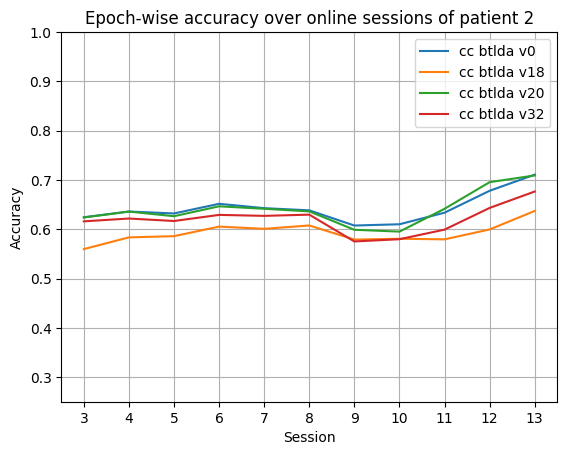

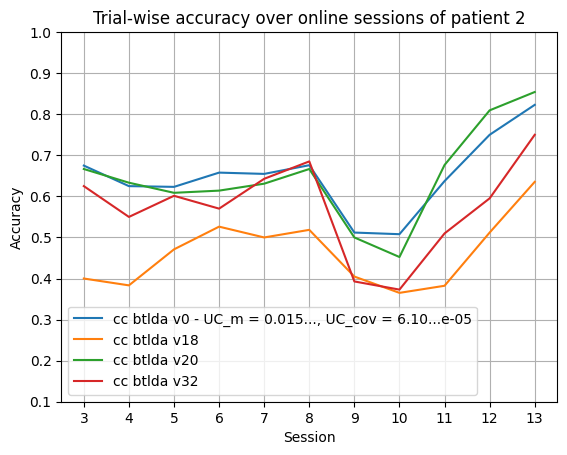

In [44]:
p =2
for id in patients_db:
    if id==p:
        lon = patients_db.get(id).get('last_session')-1

# tr long ival range
v0 = 0
with open(f'v{v0}/pickles/p{p}_cc_v{v0}.pkl', 'rb') as f:
    p_cc_v0 = pickle.load(f) 

print(p_cc_v0.keys())

v1 = 18
with open(f'v{v1}/pickles/p{p}_cc_v{v1}.pkl', 'rb') as f:
    p_cc_v1 = pickle.load(f) 

print(p_cc_v1.keys())

v2 = 20
with open(f'v{v2}/pickles/p{p}_cc_v{v2}.pkl', 'rb') as f:
    p_cc_v2 = pickle.load(f) 

print(p_cc_v2.keys())

v3 = 32
with open(f'v{v3}/pickles/p{p}_cc_v{v3}.pkl', 'rb') as f:
    p_cc_v3 = pickle.load(f) 

print(p_cc_v3.keys())


ews_cc_v0= extract_ews_v3(performances= p_cc_v0, patient_nr=p, last_online_session=lon, strategy="cc")
tws_cc_v0 = extract_tws_v3(performances= p_cc_v0, patient_nr=p, last_online_session=lon, strategy="cc")

ews_cc_v1= extract_ews_v3(performances= p_cc_v1, patient_nr=p, last_online_session=lon, strategy="cc")
tws_cc_v1 = extract_tws_v3(performances= p_cc_v1, patient_nr=p, last_online_session=lon, strategy="cc")


ews_cc_v2= extract_ews_v3(performances= p_cc_v2, patient_nr=p, last_online_session=lon, strategy="cc")
tws_cc_v2 = extract_tws_v3(performances= p_cc_v2, patient_nr=p, last_online_session=lon, strategy="cc")
ews_cc_v3= extract_ews_v3(performances= p_cc_v3, patient_nr=p, last_online_session=lon, strategy="cc")
tws_cc_v3 = extract_tws_v3(performances= p_cc_v3, patient_nr=p, last_online_session=lon, strategy="cc")

# Plot 1: epoch-wise
plt.figure()
plt.plot(ews_cc_v0, label=f"cc btlda v{v0}")
plt.plot(ews_cc_v1, label=f"cc btlda v{v1}")
plt.plot(ews_cc_v2, label=f"cc btlda v{v2}")
plt.plot(ews_cc_v3, label=f"cc btlda v{v3}")
plt.title(f"Epoch-wise accuracy over online sessions of patient {p}")
plt.legend()
plt.xlabel("Session")
plt.ylabel("Accuracy")
plt.xticks(np.arange(0,lon-2),np.arange(3,lon+1))
plt.ylim((0.25,1))
plt.grid()


# Plot 2: Trial-wise acc 

plt.figure()

plt.plot(tws_cc_v0, label=f"cc btlda v{v0} - UC_m = 0.015..., UC_cov = 6.10...e-05")
plt.plot(tws_cc_v1, label=f"cc btlda v{v1}")
plt.plot(tws_cc_v2, label=f"cc btlda v{v2}")
plt.plot(tws_cc_v3, label=f"cc btlda v{v3}")

plt.title(f"Trial-wise accuracy over online sessions of patient {p}")
plt.xlabel("Session")
plt.ylabel("Accuracy")
plt.ylim((0.1,1))
plt.grid()
plt.xticks(np.arange(0,lon-2),np.arange(3,lon+1))
#plt.yticks(np.arange(0,1.1,0.1))
#plt.xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])
#plt.xticks(np.arange(0,last_on_session-2),np.arange(3,last_on_session+1))
plt.legend(bbox_to_anchor=(1, 1.05))
plt.legend()
plt.show()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94])
version:  0
p:  2
11
p:  4
17
p:  6
13
p:  8
16
p:  10
13
70
UC_mean: 0.00390625 - UC_cov: 3.814697265625e-06
version:  1
p:  2
11
p:  4
17
p:  6
13
p:  8
16
p:  10
13
70
UC_mean: 0.00390625 - UC_cov: 7.62939453125e-06
version:  2
p:  2
11
p:  4
17
p:  6
13
p:  8
16
p:  10
13
70
UC_mean: 0.00390625 - UC_cov: 1.52587890625e-05
version:  3
p:  2
11
p:  4
17
p:  6
13
p:  8
16
p:  10
13
70
UC_mean: 0.00390625 - UC_cov: 3.0517578125e-05
version:  4
p:  2
11
p:  4
17
p:  6
13
p:  8
16
p:  10
13
70
UC_mean: 0.00390625 - UC_cov: 6.103515625e-05
version:  5
p:  2
11
p:  4
17
p:  6
13
p:  8
16
p:  10
13
70
UC_mean: 0.003

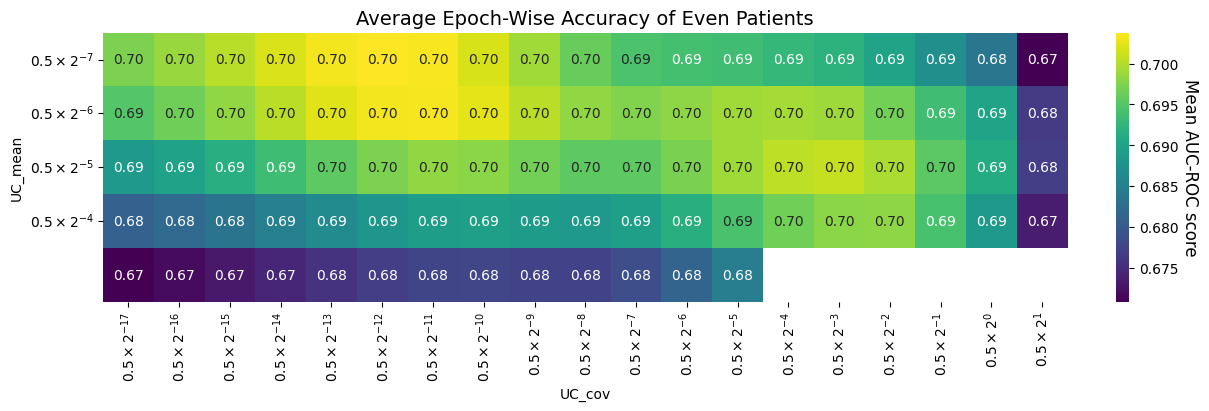

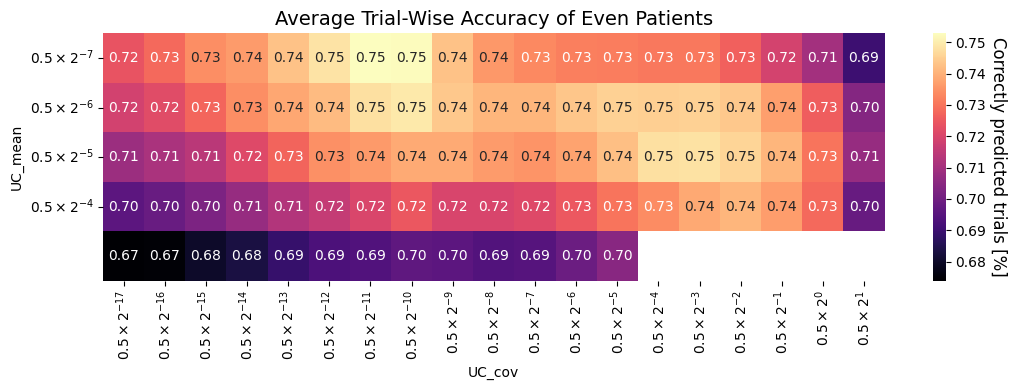

In [65]:
import pandas as pd
import seaborn as sns
from itertools import chain

def create_dict_results_UC_pairs(p, lon):
    with open(f'versions.pkl', 'rb') as f:
        versions_dict = pickle.load(f) 

    print(versions_dict.keys())
    #UC_means = []
    #UC_covs = []
    UC_pairs = []
    data = []
    

    for v,version in enumerate(versions_dict.keys()):
        ews_scores = []
        tws_scores = []
        if v<89:
            UC_m = versions_dict.get(version).get("UC_mean")
            UC_c = versions_dict.get(version).get("UC_cov")
            print("version: ",v)

            for id in patients_db:
                #if id == 3:
                if id%2==0:
                    info = patients_db.get(id)
                    p = info.get('patient_nr')
                    lon = info.get('last_session')-1

                    with open(f'v{v}/pickles/p{p}_cc_v{v}.pkl', 'rb') as f:
                        p_version_scores = pickle.load(f) 

                    print("p: ",p)
                    
                    #print(p_version_scores.get('p1_cc_s3').get('epoch-wise').get('btlda'))
                    ews_cc= extract_ews_v3(performances= p_version_scores, patient_nr=p, last_online_session=lon, strategy="cc")
                    #print("debug reached here")

                    tws_cc = extract_tws_v3(performances= p_version_scores, patient_nr=p, last_online_session=lon, strategy="cc")
                    print(len(ews_cc))
                    ews_scores.append(ews_cc.tolist())
                    tws_scores.append(tws_cc.tolist())

            ews_scores = [x for sublist in ews_scores for x in sublist]
            tws_scores = [x for sublist in tws_scores for x in sublist]
            print(len(ews_scores))

            data.append({
                "v": v,
                "UC_mean": UC_m,
                "UC_cov": UC_c,
                "EWS_mean": np.array(ews_scores[8:]).mean(),
                "TWS_mean": np.array(tws_scores[8:]).mean()
            })

            print(f"UC_mean: {UC_m} - UC_cov: {UC_c}")
            #UC_means.append(UC_m)
            #UC_covs.append(UC_c)
            UC_pairs.append(np.array([UC_m, UC_c]))

    return data

def create_dataframe(dict):
    df_long = pd.DataFrame(dict)
    return df_long

# Use
p = 9
for id in patients_db:
    if id==p:
        lon = patients_db.get(id).get('last_session')-1

data_dict = create_dict_results_UC_pairs(p=p, lon=lon)
df = create_dataframe(data_dict)
df.to_csv("cc_pairs_results.csv")

pivot_ews = df.pivot(index="UC_mean", columns="UC_cov", values="EWS_mean")
print(type(df["UC_cov"]))
# exponents = np.arange(-13, 2)  # from -13 to 1 (inclusive)
# #exponents = np.arange(0,2)
# UC_range = 0.5 * (2.0 ** exponents)
# UC_pairs = list(product(UC_range, UC_range))

# ### REDUCED RANGE
UC_mean_exponents = np.arange(-7, -2)  
UC_mean_exponents = UC_mean_exponents[:4]
UC_mean_range = 0.5 * (2.0 ** UC_mean_exponents)

UC_cov_exponents = np.arange(-17, 2)  
UC_cov_range = 0.5 * (2.0 ** UC_cov_exponents)

# UC_pairs = list(product(UC_mean_range, UC_cov_range))
# print(UC_pairs)

#ax = sns.heatmap(data, xticklabels=UC_mean_range, yticklabels=UC_cov_range, cmap="viridis")

# Format ticks in scientific notation
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import FuncFormatter
#yticklabels = []
#for x in UC_cov_exponents:
    #yticklabels.append()
# Set scientific notation for x-axis and y-axis ticks


# Plot heatmap
plt.figure(figsize=(12, 4), constrained_layout=True)
#sns.heatmap(pivot_ews, annot=True, fmt=".2f", cmap="viridis")
ax = sns.heatmap(pivot_ews, annot=True, fmt=".2f", cmap="viridis")
ax.set_xticks(np.arange(len(UC_cov_range)) + 0.5)
ax.set_yticks(np.arange(len(UC_mean_range)) + 0.5)
ax.set_xticklabels([fr"$0.5 \times 2^{{{x}}}$" for x in UC_cov_exponents], rotation=90, fontsize=10)
ax.set_yticklabels([fr"$0.5 \times 2^{{{y}}}$" for y in UC_mean_exponents], rotation=0, fontsize=10)
#plt.rcParams.update({'font.size': 8})
# plt.rcParams.update({
#     'axes.titlesize': 10,
#     'axes.labelsize': 12,
#     'xtick.labelsize': 8,
#     'ytick.labelsize': 8,
#     'legend.fontsize': 8
# })
# plt.xticks(UC_mean_range[:4], ['{:.1e}'.format(x) for x in UC_mean_range[:4]], rotation=45, ha='right')
# plt.yticks(UC_cov_range, ['{:.1e}'.format(y) for y in UC_cov_range], rotation=0)
cbar = ax.collections[0].colorbar
cbar.set_label("Mean AUC-ROC score", fontsize=12, rotation=270, labelpad=15)
# Move the colorbar closer to the heatmap
# cbar.ax.set_position([
#     cbar.ax.get_position().x0 -0.8,  # shift left
#     cbar.ax.get_position().y0,
#     cbar.ax.get_position().width,
#     cbar.ax.get_position().height
# ])
plt.title("Average Epoch-Wise Accuracy of Even Patients", fontsize=14)
plt.ylabel("UC_mean")
plt.xlabel("UC_cov")
# plt.tight_layout()
plt.show()

pivot_tws = df.pivot(index="UC_mean", columns="UC_cov", values="TWS_mean")

# Plot heatmap
plt.figure(figsize=(11, 4))
ax = sns.heatmap(pivot_tws, annot=True, fmt=".2f", cmap="magma")
# HP (sessions 11-17)
# 6D (sessions 3-10)
ax.set_xticks(np.arange(len(UC_cov_range)) + 0.5)
ax.set_yticks(np.arange(len(UC_mean_range)) + 0.5)
ax.set_xticklabels([fr"$0.5 \times 2^{{{x}}}$" for x in UC_cov_exponents], rotation=90, fontsize=10)
ax.set_yticklabels([fr"$0.5 \times 2^{{{y}}}$" for y in UC_mean_exponents], rotation=0, fontsize=10)
cbar = ax.collections[0].colorbar
cbar.set_label("Correctly predicted trials [%]", fontsize=12, rotation=270, labelpad=15)
plt.title("Average Trial-Wise Accuracy of Even Patients", fontsize=14)
plt.ylabel("UC_mean")
plt.xlabel("UC_cov")
plt.tight_layout()
plt.show()